# Model: Random Forest

This notebook trains and evaluates a **Random Forest** model to predict crash severity (0 = No Injury, 1 = Injury, 2 = Fatality) using the cleaned NYC collision dataset.

This model tests a robust ensemble baseline that can learn nonlinear interactions and handle feature mixtures better than Logistic Regression.


---
## 1. Load Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')


Libraries loaded.


---
## 2. Load Dataset

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 394,751 rows x 29 columns


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,num_injured,...,collision_id,vehicle_type_1,vehicle_type_2,severity,year,month,day_of_week,hour,is_weekend,is_rush_hour
0,2022-01-01,7:33,UNKNOWN,UNKNOWN,40.771477,-73.91824,"(40.771477, -73.91824)",HOYT AVENUE NORTH,UNKNOWN,0,...,4491400,SEDAN,UNKNOWN,0,2022,1,Saturday,7,1,1
1,2022-01-01,4:30,UNKNOWN,UNKNOWN,NaN,NaN,NaN,SOUTHERN PARKWAY,JFK EXPRESSWAY,0,...,4491626,SEDAN,SEDAN,0,2022,1,Saturday,4,1,0
2,2022-01-01,7:57,UNKNOWN,UNKNOWN,NaN,NaN,NaN,WESTCHESTER AVENUE,SHERIDAN EXPRESSWAY,0,...,4491734,SEDAN,UNKNOWN,0,2022,1,Saturday,7,1,1
3,2022-01-01,5:17,UNKNOWN,UNKNOWN,40.746930,-73.84866,"(40.74693, -73.84866)",GRAND CENTRAL PKWY,UNKNOWN,1,...,4491857,SEDAN,SEDAN,1,2022,1,Saturday,5,1,0
4,2022-01-01,1:30,UNKNOWN,UNKNOWN,40.819157,-73.96038,"(40.819157, -73.96038)",HENRY HUDSON PARKWAY,UNKNOWN,0,...,4491344,SEDAN,STATION WAGON/SPORT UTILITY VEHICLE,0,2022,1,Saturday,1,1,0


---
## 3. Define Features and Target

The **target** is `severity` (0 = No Injury, 1 = Injury, 2 = Fatality).

### Columns excluded to prevent data leakage

**Direct leakage — injury/fatality counts:**
These columns describe the *outcome* of the crash and must never be model features.

| Column | Why excluded |
| --- | --- |
| `num_injured`, `num_killed` | Used to define severity target |
| `number_of_pedestrians_injured/killed` | Sub-components of the target |
| `number_of_cyclist_injured/killed` | Sub-components of the target |
| `number_of_motorist_injured/killed` | Sub-components of the target |

**Other excluded columns:**

| Column | Why excluded |
| --- | --- |
| `collision_id` | Just an ID — no predictive signal |
| `crash_date`, `crash_time` | Replaced by extracted time features |
| `on_street_name`, `cross_street_name`, `location` | High cardinality — memory explosion |
| `zip_code` | High cardinality and limited interpretability in this baseline model |

In [3]:
DROP_COLS = [
    # Target and its direct source columns (leakage)
    'severity',
    'num_injured', 'num_killed',
    'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
    'number_of_cyclist_injured',     'number_of_cyclist_killed',
    'number_of_motorist_injured',    'number_of_motorist_killed',
    # ID — no signal
    'collision_id',
    # Replaced by extracted time features
    'crash_date', 'crash_time',
    # High cardinality — memory explosion
    'on_street_name', 'cross_street_name', 'location',
]

feature_cols = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_cols].copy()
y = df['severity'].copy()

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'\nTarget distribution:\n{y.value_counts().rename({0: "No Injury", 1: "Injury", 2: "Fatality"})}')

Features (14): ['borough', 'zip_code', 'latitude', 'longitude', 'factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2', 'year', 'month', 'day_of_week', 'hour', 'is_weekend', 'is_rush_hour']

Target distribution:
severity
No Injury    230535
Injury       163164
Fatality       1052
Name: count, dtype: int64


---
## 4. Time-Based Train / Test Split

We split by **year** rather than randomly to simulate real-world deployment:
- **Train:** 2022 – 2024
- **Test:** 2025

A random split would let the model train on 2025 crashes and test on 2022 ones — unrealistic and inflates metrics.

In [4]:
train_mask = df['year'] <= 2024
test_mask  = df['year'] == 2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'\nTest severity distribution:\n{y_test.value_counts().rename({0: "No Injury", 1: "Injury", 2: "Fatality"})}')

Train size: 291,808  |  Test size: 85,534

Test severity distribution:
severity
No Injury    48121
Injury       37199
Fatality       214
Name: count, dtype: int64


---
## 5. Encode Categorical Variables

Logistic Regression requires numeric inputs. We use `pd.get_dummies` to one-hot encode the low-cardinality categorical columns only.

After encoding, test columns are reindexed to match train exactly — no `.align()` needed.

In [5]:
# Cap high-cardinality columns to top N values before encoding
# factor_vehicle_1/2 and vehicle_type_1/2 can have 50–900 unique values
# keeping only top 20 prevents hundreds of dummy columns from being created
def cap_to_top_n(df_train, df_test, col, n=20):
    top_vals = df_train[col].value_counts().nlargest(n).index
    df_train[col] = df_train[col].where(df_train[col].isin(top_vals), other='OTHER')
    df_test[col]  = df_test[col].where(df_test[col].isin(top_vals),  other='OTHER')
    return df_train, df_test

HIGH_CAT = ['factor_vehicle_1', 'factor_vehicle_2', 'vehicle_type_1', 'vehicle_type_2']
for col in HIGH_CAT:
    if col in X_train.columns:
        X_train, X_test = cap_to_top_n(X_train, X_test, col, n=20)

# Encode all categorical columns
CAT_COLS = ['borough', 'day_of_week'] + HIGH_CAT
CAT_COLS = [c for c in CAT_COLS if c in X_train.columns]

# Drop zip_code — still a string, too many unique values
X_train = X_train.drop(columns=['zip_code'], errors='ignore')
X_test  = X_test.drop(columns=['zip_code'], errors='ignore')

X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=CAT_COLS, drop_first=True)

# Align test to train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Fill remaining NaN
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print(f'WARNING: still object columns: {remaining_obj}')
else:
    print('All columns numeric — ready to train.')

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

All columns numeric — ready to train.
X_train: (291808, 98)  |  X_test: (85534, 98)


---
## 6. Train Random Forest — Model Comparison

We train **three variants** to find the best class-weight strategy:

| Variant | `class_weight` | Goal |
| --- | --- | --- |
| A | `None` | Maximize overall accuracy (ignores imbalance) |
| B | `'balanced'` | Auto-weights inversely proportional to class frequency |
| C | `{0:1, 1:2, 2:5}` | Manual weights — penalizes missing Injuries and Fatalities more |

The variant with the best **macro F1-score** (treats all classes equally) is selected.


In [ ]:
from sklearn.metrics import f1_score

variants = {
    'A — no weight': None,
    'B — balanced': 'balanced',
    'C — custom {0:1,1:2,2:5}': {0: 1, 1: 2, 2: 5},
}

results = {}
for name, cw in variants.items():
    m = RandomForestClassifier(
        n_estimators=200, class_weight=cw, random_state=42, n_jobs=-1
    )
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    macro_f1 = f1_score(y_test, preds, average='macro')
    results[name] = {'model': m, 'preds': preds, 'macro_f1': macro_f1}
    print(f'{name:35s}  macro F1 = {macro_f1:.4f}')

# Select best model by macro F1
best_name = max(results, key=lambda k: results[k]['macro_f1'])
model  = results[best_name]['model']
y_pred = results[best_name]['preds']
print(f'Best variant: {best_name}')


A — no weight                        macro F1 = 0.4302
B — balanced                         macro F1 = 0.3722
C — custom {0:1,1:2,2:5}             macro F1 = 0.3646

Best variant: A — no weight


---
## 7. Evaluate the Best Model

In [7]:
y_pred = model.predict(X_test)

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['No Injury', 'Injury', 'Fatality']
))

Classification Report:
              precision    recall  f1-score   support

   No Injury       0.66      0.87      0.75     48121
      Injury       0.71      0.43      0.54     37199
    Fatality       0.00      0.00      0.00       214

    accuracy                           0.68     85534
   macro avg       0.46      0.43      0.43     85534
weighted avg       0.68      0.68      0.66     85534



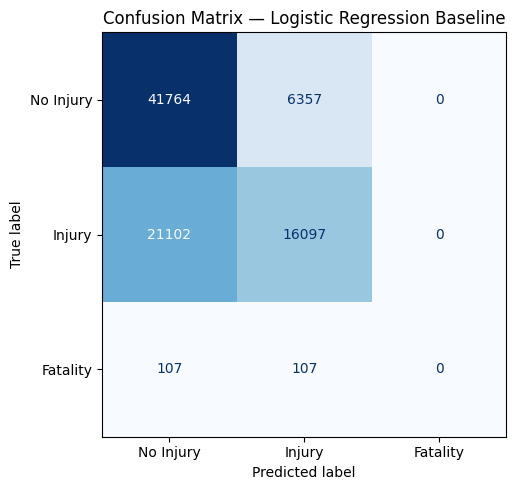

In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Injury', 'Injury', 'Fatality'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.show()

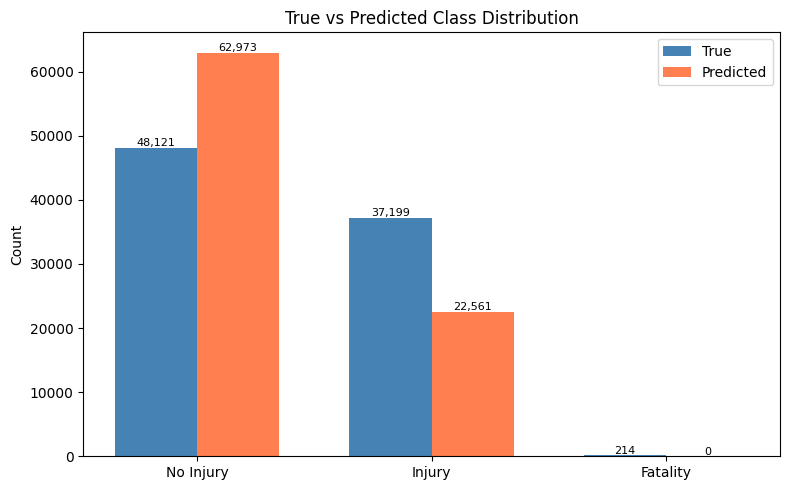

In [9]:
# True vs Predicted class distribution
labels = ['No Injury', 'Injury', 'Fatality']
true_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index().reindex([0, 1, 2], fill_value=0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, true_counts, width, label='True',      color='steelblue')
ax.bar(x + width/2, pred_counts, width, label='Predicted', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.set_title('True vs Predicted Class Distribution')
ax.legend()
for i, (t, p) in enumerate(zip(true_counts, pred_counts)):
    ax.text(i - width/2, t + 200, f'{t:,}', ha='center', fontsize=8)
    ax.text(i + width/2, p + 200, f'{p:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

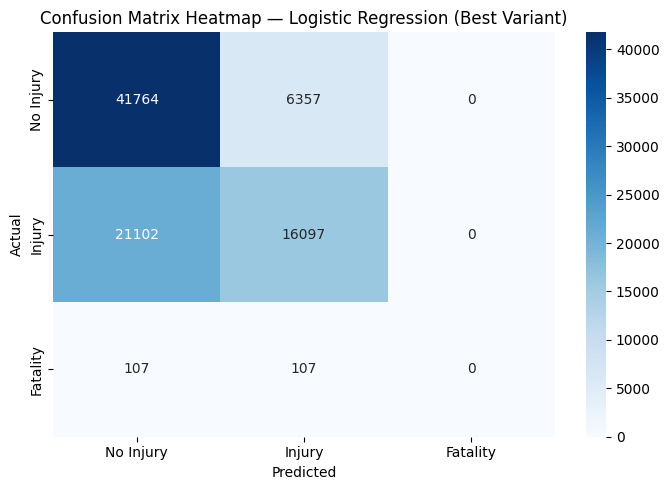

In [10]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Injury', 'Injury', 'Fatality'],
    yticklabels=['No Injury', 'Injury', 'Fatality'],
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix Heatmap — Logistic Regression (Best Variant)')
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

Random Forest calculates feature importance based on how much each feature reduces impurity across the ensemble.
This gives a sense of which predictors the model finds most valuable in separating crash severity classes.


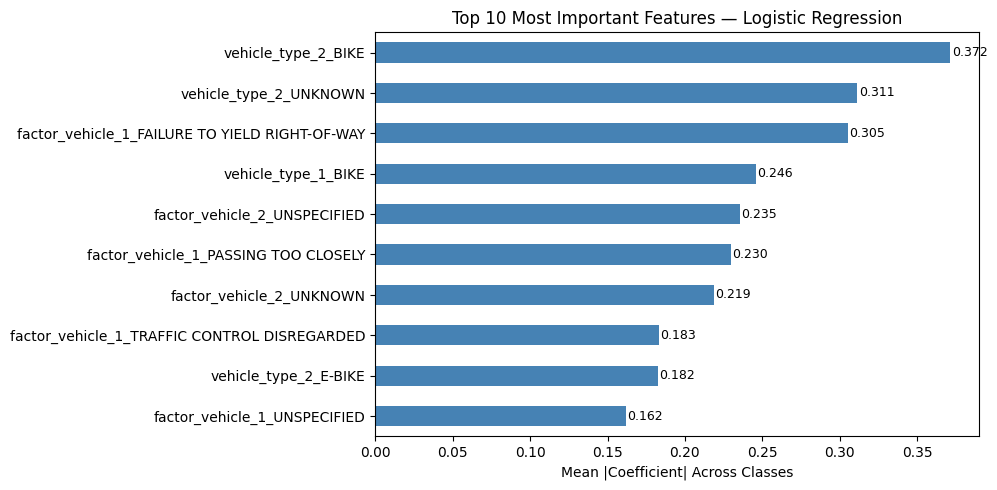


Top 10 features:
vehicle_type_2_BIKE                               0.371502
vehicle_type_2_UNKNOWN                            0.311460
factor_vehicle_1_FAILURE TO YIELD RIGHT-OF-WAY    0.305238
vehicle_type_1_BIKE                               0.245875
factor_vehicle_2_UNSPECIFIED                      0.235477
factor_vehicle_1_PASSING TOO CLOSELY              0.229676
factor_vehicle_2_UNKNOWN                          0.218608
factor_vehicle_1_TRAFFIC CONTROL DISREGARDED      0.183062
vehicle_type_2_E-BIKE                             0.182430
factor_vehicle_1_UNSPECIFIED                      0.161884


In [ ]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
importance[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Most Important Features — Random Forest')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
for i, v in enumerate(importance[::-1]):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance.to_string())


---
## 9. Observations

### Strengths of Random Forest
Random Forest learns nonlinear interactions and can capture more complex crash severity patterns than a linear model.

### Class imbalance remains important
Fatality is still a rare event (~0.27% of the test set), so class weighting and additional imbalance strategies are often necessary to improve recall for the minority class.

### Feature importance
The ranking of top features helps validate whether the model is using sensible signals like vehicle type, contributing factors, and crash context rather than spurious artifacts.

### Next steps
Compare this Random Forest baseline against Logistic Regression using the same feature set. If the model still underpredicts Fatality, consider resampling, focal loss, or specialized minority-class ensembles.
